Importing libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

Loading test data

In [18]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

Loading the best model - Random Forest

In [19]:
rf_model = joblib.load("../models/random_forest_model.pkl")

In [20]:
y_pred = rf_model.predict(X_test)

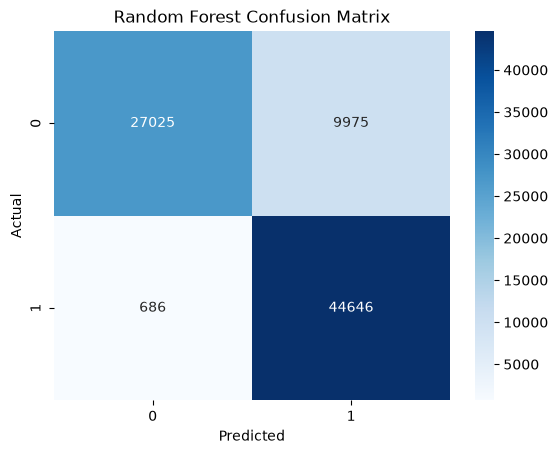

In [21]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.73      0.84     37000
           1       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



ROC Curve

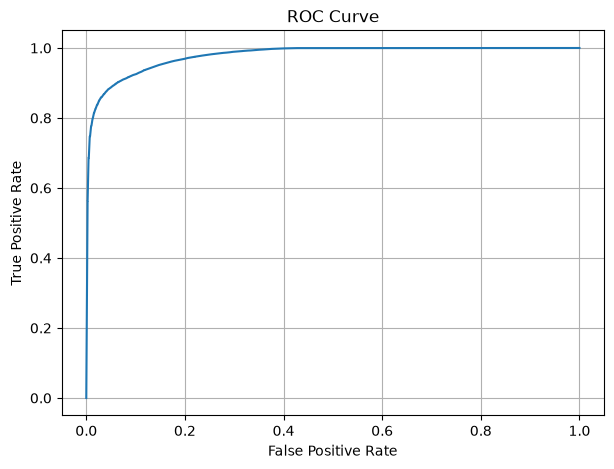

In [23]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

AUC Score

In [24]:
auc = roc_auc_score(y_test,y_prob)

print("AUC:", auc)

AUC: 0.9780298053281375


Feature Importance

In [25]:
feature_names = np.load("../data/processed/feature_names.npy",allow_pickle=True)

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
6,num__sttl,0.118284
28,num__ct_state_ttl,0.074900
7,num__dttl,0.056034
9,num__dload,0.054569
5,num__rate,0.051562
8,num__sload,0.041480
20,num__tcprtt,0.033347
3,num__sbytes,0.032746
12,num__sinpkt,0.030070
2,num__dpkts,0.029819


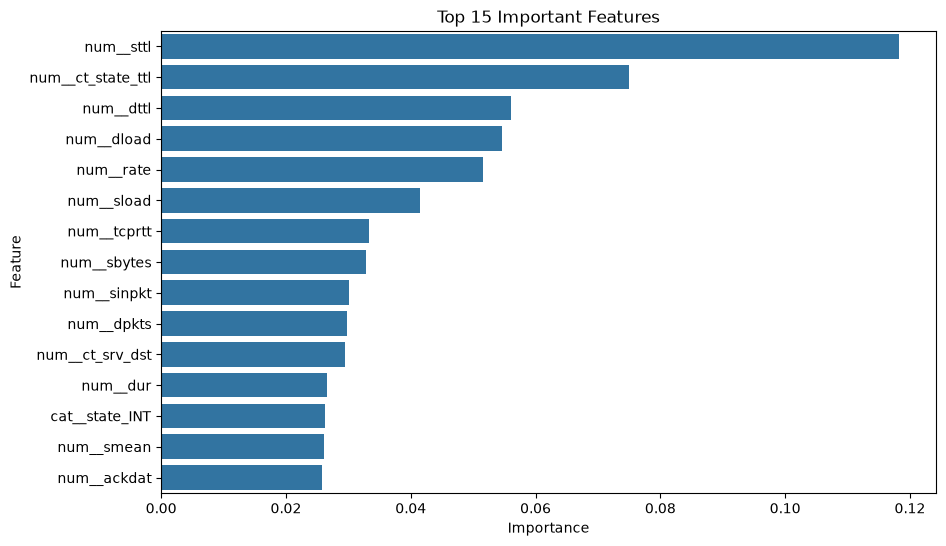

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.show()

### Feature Importance Analysis

The Random Forest model identified network traffic characteristics such as source/destination TTL, packet rate, data load, and TCP timing features as the most influential features for intrusion detection.

The importance of TTL and traffic volume-related features suggests that malicious traffic exhibits different network behavior patterns compared to normal traffic.